
# Khipus.ai  
## Unsupervised Learning  
### Clustering Algorithms  
<span>© Copyright Notice 2025, Khipus.ai - All Rights Reserved.</span>  

### Assignment 4  
### Name: Gabriel Severiche  



## Assignment Instructions

In this assignment, you will perform a clustering analysis on country locations using latitude and longitude data.  
You will follow these steps:

1. **Import the relevant libraries.**  
2. **Load the dataset (`countries.csv`).**  
3. **Visualize the data by plotting longitude vs. latitude.**  
4. **Select the features for clustering.**  
5. **Perform clustering analysis and Evaluate clustering results.**  
6. **Explore clustering solutions and select the number of clusters** 

Ensure that you document your analysis and interpretations in Markdown cells.  


1. Import the relevant libraries.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


2. Load the dataset (countries.csv).

In [3]:
# Load the dataset

# your code here

data = pd.read_csv("countries.csv")

# Display the first few rows

data.head()


,country,latitude,longitude,name
0,AD,42.546245,1.601554,Andorra
1,AE,23.424076,53.847818,United Arab Emirates
2,AF,33.939110,67.709953,Afghanistan
3,AG,17.060816,-61.796428,Antigua and Barbuda
4,AI,18.220554,-63.068615,Anguilla


4. Visualize the data by plotting longitude vs. latitude.

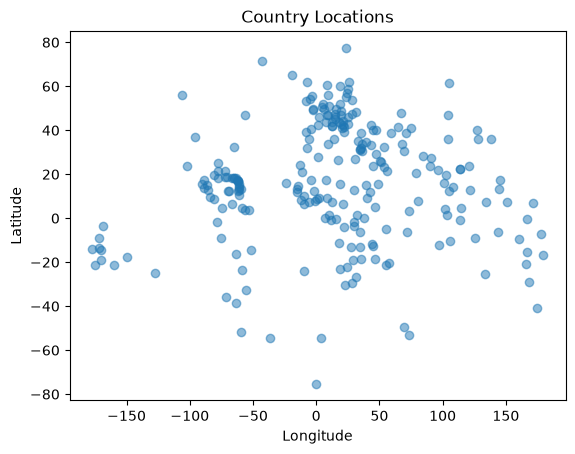

In [5]:
# Scatter plot of country locations (Longitude vs Latitude)
# your code here
plt.scatter(x=data['longitude'], y=data['latitude'], alpha=0.5)
plt.title('Country Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()



4. Select the features for clustering.

In [7]:
# Selecting features for clustering
features = data[['longitude', 'latitude']]
features.head()

,longitude,latitude
0,1.601554,42.546245
1,53.847818,23.424076
2,67.709953,33.939110
3,-61.796428,17.060816
4,-63.068615,18.220554


Standardize the features for clustering and Drop rows with missing values

In [8]:
# Standardize the features for clustering
# scaler = StandardScaler()
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
X_scaled = scaler.fit_transform(features)
# Drop rows with missing values
dropna = pd.DataFrame(X_scaled).dropna()
# X_scaled = X_scaled[~np.isnan(X_scaled).any(axis=1)]
X_scaled = X_scaled[~np.isnan(X_scaled).any(axis=1)]


5.Perform clustering analysis using the Elbow method to find the optimal number of clusters

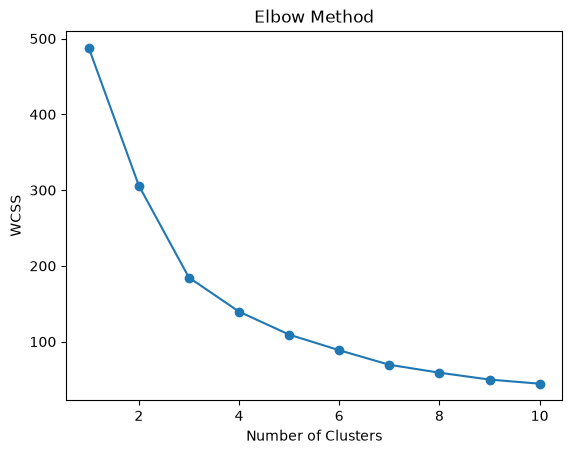

In [15]:
# Using the Elbow method to find the optimal number of clusters
# your code here
# Plot the Elbow curve
# Using the Elbow method to find the optimal number of clusters

wcss = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow curve
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()



6.Explore clustering solutions and select the number of clusters

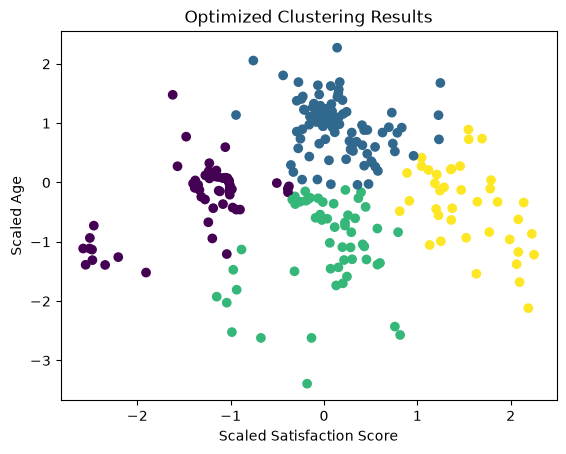

In [18]:
# Drop rows with missing values in the original DataFrame
# Selecting the optimal number of clusters based on the Elbow method
# your code here
# Adjust based on the elbow plot

df_cleaned = data.dropna(subset=['longitude', 'latitude'])
optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
kmeans.fit(X_scaled)
# Performing clustering
df_cleaned['Cluster_Optimized'] = kmeans.labels_


# Visualizing the clustering results
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans.labels_,
    cmap="viridis"
)
plt.title("Optimized Clustering Results")
plt.xlabel("Scaled Satisfaction Score")
plt.ylabel("Scaled Age")
plt.show()